## filter by resolution (< 2.0) and deposition (2021/09/30)

In [ ]:
import pandas as pd

# CSV 파일 불러오기 (열 이름 없음)
metadata = pd.read_csv('/public_data/BioMolDB_2024Oct21/metadata/ID_to_deposition.csv', header=None)

# 날짜, 해상도 열 추출
metadata[1] = pd.to_datetime(metadata[1], errors='coerce')  # 날짜 형식으로 변환
metadata[2] = pd.to_numeric(metadata[2], errors='coerce')   # 숫자형으로 변환

# 조건: 2021-09-30 이전 & resolution < 3
filtered = metadata[
    (metadata[1] < pd.to_datetime('2021-09-30')) &
    (metadata[2] <= 2)
]

# 결과 저장
filtered.to_csv('/home/psh/protein-frame-flow/biomol/resolution_date_filtered_ID.csv', index=False, header=False)


## check number of samples by resolution threshold 

/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2803209/3820973739.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_280

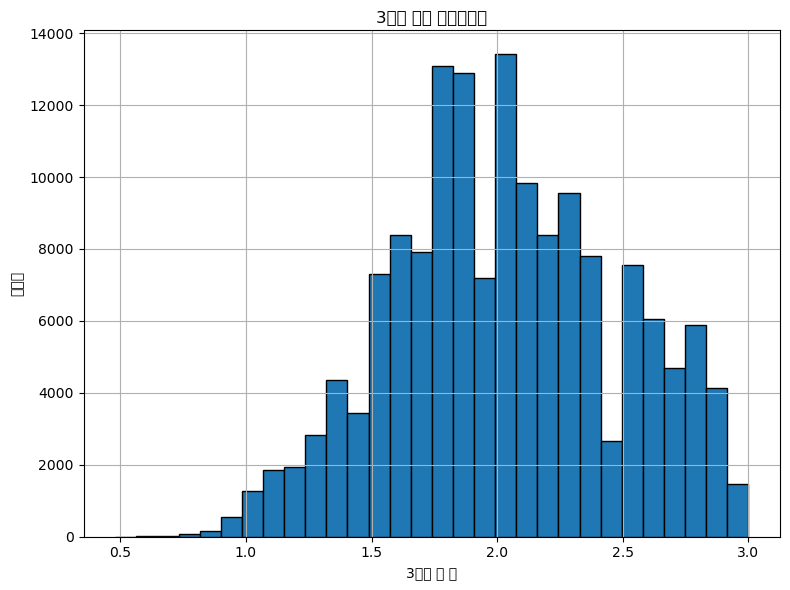

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 읽기
csv_path = "/home/psh/protein-frame-flow/parse_general/resolution_date_filtered_ID.csv"
df = pd.read_csv(csv_path)

# 3번째 열 추출 (0-indexed이므로 인덱스 2)
third_column = df.iloc[:, 2]

# 히스토그램 그리기
plt.figure(figsize=(8, 6))
plt.hist(third_column.dropna(), bins=30, edgecolor='black')
plt.xlabel("3번째 열 값")
plt.ylabel("빈도수")
plt.title("3번째 열의 히스토그램")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# CSV 파일 읽기
csv_path = "/home/psh/protein-frame-flow/parse_general/resolution_date_filtered_ID.csv"
df = pd.read_csv(csv_path)

# 3번째 열 가져오기 (숫자형으로 변환, 오류는 NaN으로 처리)
third_column = pd.to_numeric(df.iloc[:, 2], errors='coerce')

# threshold 설정
threshold = 2.0

# threshold 미만 개수 세기
count_below_threshold = (third_column < threshold).sum()

print(f"값이 {threshold} 미만인 개수: {count_below_threshold}")


값이 2.0 미만인 개수: 73642


In [ ]:
import pandas as pd

# CSV 파일 경로
input_path = "/home/psh/protein-frame-flow/parse_general/resolution_date_filtered_ID.csv"
output_path = "/home/psh/protein-frame-flow/parse_general/resolution_le_2.0.csv"

# CSV 불러오기
df = pd.read_csv(input_path)

# 3번째 열 이름 가져오기 (혹은 직접 'df.columns[2]'로 인덱싱)
col_name = df.columns[2]

# 숫자로 변환 (에러가 있는 경우 NaN으로)
df[col_name] = pd.to_numeric(df[col_name], errors='coerce')

# 해상도 ≤ 2.0만 필터링
filtered_df = df[df[col_name] <= 2.0]

# 새로운 CSV로 저장
filtered_df.to_csv(output_path, index=False)

print(f"해상도 ≤ 2.0 Å인 구조: {len(filtered_df)}개")
print(f"저장 완료: {output_path}")


해상도 ≤ 2.0 Å인 구조: 81982개
저장 완료: /home/psh/protein-frame-flow/parse_interface/resolution_le_2.0.csv


In [ ]:
import pandas as pd

# 파일 경로
txt_path = "/home/psh/protein-frame-flow/parse_general/only_protein.txt"
csv_path = "/home/psh/protein-frame-flow/parse_general/resolution_2.0.csv"
output_txt_path = "/home/psh/protein-frame-flow/parse_general/only_protein_filtered.txt"

# 텍스트 파일에서 PDB ID 불러오기
with open(txt_path, 'r') as f:
    txt_ids = set(line.strip().lower() for line in f if line.strip())

# CSV 파일 불러오기
df = pd.read_csv(csv_path)
csv_ids = set(df.iloc[:, 0].astype(str).str.lower())

# 공통된 ID만 필터링
filtered_ids = sorted(txt_ids & csv_ids)

# 저장
with open(output_txt_path, 'w') as f:
    for pdb_id in filtered_ids:
        f.write(f"{pdb_id}\n")

print(f"총 {len(filtered_ids)}개의 PDB ID를 저장했습니다: {output_txt_path}")


총 78977개의 PDB ID를 저장했습니다: /home/psh/protein-frame-flow/parse_interface/only_protein_filtered.txt


## make metadata_psh 

In [ ]:
import pandas as pd

# 파일 경로
csv_input_path = "/public_data/BioMolDB_2024Oct21/metadata/metadata_psk.csv"
txt_path = "/home/psh/protein-frame-flow/parse_general/only_protein_filtered.txt"
csv_output_path = "/home/psh/protein-frame-flow/parse_general/metadata_psh.csv"

# 1. 텍스트 파일에서 유효한 PDB ID 불러오기
with open(txt_path, 'r') as f:
    valid_ids = set(line.strip().lower() for line in f if line.strip())

# 2. metadata_psk.csv 파일 불러오기
df = pd.read_csv(csv_input_path)

# 3. CHAINID 열에서 PDB ID 추출 (예: 1ABC_A → 1abc)
pdb_ids_from_chainid = df["CHAINID"].astype(str).str.split('_').str[0].str.lower()

# 4. valid_ids에 포함되는 PDB ID만 필터링
filtered_df = df[pdb_ids_from_chainid.isin(valid_ids)]

# 5. 필터링된 결과 저장
filtered_df.to_csv(csv_output_path, index=False)

print(f"{len(filtered_df)}개의 행이 저장되었습니다: {csv_output_path}")


160939개의 행이 저장되었습니다: /home/psh/protein-frame-flow/parse_interface/metadata_psh.csv


## polymer mask 정제하기 

In [25]:
import os
import json

def group_close_values(values, threshold=5):
    if not values:
        return []

    values = sorted(values)
    grouped = [[values[0]]]

    for v in values[1:]:
        if v - grouped[-1][-1] < threshold:
            grouped[-1].append(v)
        else:
            grouped.append([v])

    return grouped

def process_interface_directory(json_dir):
    for filename in os.listdir(json_dir):
        if not filename.endswith('.json'):
            continue

        filepath = os.path.join(json_dir, filename)

        with open(filepath, 'r') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON file: {filename}")
                continue

        if "interface_residues" not in data:
            print(f"Skipping {filename}: no 'interface_residues' key.")
            continue

        skip_file = False
        for chain_idx, residue_list in data["interface_residues"].items():
            # 이미 그룹핑되어 있다면 (리스트 안에 또 리스트가 있는 경우)
            if residue_list and isinstance(residue_list[0], list):
                print(f"Skipping {filename}: already grouped.")
                skip_file = True
                break
        if skip_file:
            continue

        print(f"Processing {filename}")
        new_interface_residues = {}

        for chain_idx, residue_list in data["interface_residues"].items():
            new_interface_residues[chain_idx] = group_close_values(residue_list)

        # 덮어쓰기
        data["interface_residues"] = new_interface_residues

        with open(filepath, 'w') as f:
            json.dump(data, f, indent=4)

# 사용 예시
json_directory_path = "/home/psh/data/general/masking_index/"
process_interface_directory(json_directory_path)

Skipping 102l.json: no 'interface_residues' key.
Skipping 102m.json: no 'interface_residues' key.
Skipping 103l.json: no 'interface_residues' key.
Skipping 104m.json: no 'interface_residues' key.
Skipping 106m.json: no 'interface_residues' key.
Skipping 107l.json: no 'interface_residues' key.
Skipping 108l.json: no 'interface_residues' key.
Skipping 109l.json: no 'interface_residues' key.
Skipping 109m.json: no 'interface_residues' key.
Skipping 110l.json: no 'interface_residues' key.
Skipping 110m.json: no 'interface_residues' key.
Skipping 111l.json: no 'interface_residues' key.
Skipping 111m.json: no 'interface_residues' key.
Skipping 112l.json: no 'interface_residues' key.
Skipping 113l.json: no 'interface_residues' key.
Skipping 114l.json: no 'interface_residues' key.
Skipping 115l.json: no 'interface_residues' key.
Skipping 118l.json: no 'interface_residues' key.
Skipping 119l.json: no 'interface_residues' key.
Skipping 11bg.json: already grouped.
Skipping 120l.json: no 'interfac

## open pkl filepath 

In [4]:
from data.utils import read_pkl

pkl_file = read_pkl('/home/psh/data/general/meta/1a1a.pkl')
print(pkl_file.keys())

dict_keys(['atom_positions', 'aatype', 'atom_mask', 'residue_index', 'chain_index', 'b_factors', 'bb_mask', 'bb_positions', 'modeled_idx'])


In [6]:
print(pkl_file['chain_index'])

[26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26
 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26
 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26
 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26 26
 26 26 26 26 26 26 26 26 26 26 28 27 27 27 27 27 27 27 27 27 27 27 27 27
 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27
 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27
 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27
 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 27 29]


In [ ]:
import pandas as pd

csv_path = "/home/psh/data/general/meta/metadata.csv"
df = pd.read_csv(csv_path)

filtered_rows = df[df["seq_len"] < 3]

# pdb_name과 seq_len 열만 선택
result = filtered_rows[["pdb_name", "seq_len"]]

print(result)

      pdb_name  seq_len
171       1a7z        2
204       1aa5        2
835       1c0q        2
836       1c0r        2
3314      1hc0        1
...        ...      ...
76450     7ltb        2
76725     7mhl        1
76726     7mhm        1
76727     7mho        1
76728     7mhq        1

[93 rows x 2 columns]


## test create pickle file 

In [3]:
import os
import gzip
from Bio.PDB.Chain import Chain as BioChain
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
import io

import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import argparse
import dataclasses
import functools as fn
import pandas as pd
import os
import multiprocessing as mp
import time
import numpy as np
import yaml

from data import utils as du
from data import parsers
from data import errors

import string 
import tempfile 
import copy

def generate_chain_id_map(chain_ids):
    """
    기존 chain_ids 리스트를 받아서 각 chain_id를 1글자 ID로 매핑해줌.
    충돌이 없도록 기존 1글자 chain_id는 그대로 쓰고, 그 외는 새롭게 부여.
    """
    available_ids = list(string.ascii_uppercase + string.ascii_lowercase + string.digits)
    used_ids = set(c for c in chain_ids if len(c) == 1)
    for uid in used_ids:
        if uid in available_ids:
            available_ids.remove(uid)

    chain_id_map = {}
    for cid in chain_ids:
        if len(cid) == 1:
            chain_id_map[cid] = cid  # 그대로 사용
        else:
            if not available_ids:
                raise ValueError("Not enough unique 1-letter chain IDs available.")
            chain_id_map[cid] = available_ids.pop(0)

    return chain_id_map
 
def get_cif_path(cif_ID):
    cif_path = (
        "/public_data/BioMolDB_2024Oct21/cif/"
        + cif_ID[1:3]
        + "/"
        + cif_ID
        + ".cif.gz"
    )
    return cif_path

def mmcif_to_cif_text(gz_path: str) -> io.StringIO:
    with gzip.open(gz_path, 'rt') as f_in:
        cif_content = f_in.read()

    mmcif_dict = MMCIF2Dict(io.StringIO(cif_content))

    # 필요한 필드 추출
    group_PDBs  = mmcif_dict.get("_atom_site.group_PDB", [])
    atom_ids    = mmcif_dict.get("_atom_site.label_atom_id", [])
    comp_ids    = mmcif_dict.get("_atom_site.label_comp_id", [])
    asym_ids    = mmcif_dict.get("_atom_site.label_asym_id", [])
    seq_ids     = mmcif_dict.get("_atom_site.label_seq_id", [])
    alt_ids     = mmcif_dict.get("_atom_site.label_alt_id", [])
    entity_ids  = mmcif_dict.get("_atom_site.label_entity_id", [])
    x_coords    = mmcif_dict.get("_atom_site.Cartn_x", [])
    y_coords    = mmcif_dict.get("_atom_site.Cartn_y", [])
    z_coords    = mmcif_dict.get("_atom_site.Cartn_z", [])
    occupancies = mmcif_dict.get("_atom_site.occupancy", [])
    b_factors   = mmcif_dict.get("_atom_site.B_iso_or_equiv", [])
    elements    = mmcif_dict.get("_atom_site.type_symbol", [])
    model_nums  = mmcif_dict.get("_atom_site.pdbx_PDB_model_num", [])

    # auth 필드
    auth_seq_ids   = mmcif_dict.get("_atom_site.auth_seq_id", [])
    auth_comp_ids  = mmcif_dict.get("_atom_site.auth_comp_id", [])
    auth_asym_ids  = mmcif_dict.get("_atom_site.auth_asym_id", [])
    auth_atom_ids  = mmcif_dict.get("_atom_site.auth_atom_id", [])
    formal_charges = mmcif_dict.get("_atom_site.pdbx_formal_charge", [])
    ins_codes       = mmcif_dict.get("_atom_site.pdbx_PDB_ins_code", [])

    n_atoms = len(atom_ids)
    residue_dict = defaultdict(lambda: defaultdict(list))

    # 1. residue_dict 생성
    for i in range(n_atoms):
        if group_PDBs[i] != "ATOM":
            continue
        if comp_ids[i] in ("HOH", "WAT"):
            continue

        alt_id = alt_ids[i] if alt_ids[i] not in ('?', '.', '') else '.'
        occ = float(occupancies[i]) if occupancies[i] != '?' else 1.0
        residue_key = (asym_ids[i], seq_ids[i])  # (chain_id, residue_id)
        residue_dict[residue_key][alt_id].append((occ, i))

    # 2. alt_id 선택
    selected_indices = []

    for alt_groups in residue_dict.values():
        # 1. '.' altLoc인 애들 먼저 무조건 선택
        if '.' in alt_groups:
            selected_indices.extend([i for occ, i in alt_groups['.']])
        
        # 2. '.' 외의 altLoc 후보들 처리
        non_dot_alts = {k: v for k, v in alt_groups.items() if k != '.'}
        if non_dot_alts:
            best_alt_id = max(
                non_dot_alts.items(),
                key=lambda kv: sum(occ for occ, _ in kv[1]) / len(kv[1])
            )[0]
            selected_indices.extend([i for occ, i in non_dot_alts[best_alt_id]])
    # 출력 필드 정의
    atom_site_keys = [
        "_atom_site.group_PDB",
        "_atom_site.id",
        "_atom_site.type_symbol",
        "_atom_site.label_atom_id",
        "_atom_site.label_alt_id",
        "_atom_site.label_comp_id",
        "_atom_site.label_asym_id",
        "_atom_site.label_entity_id",
        "_atom_site.label_seq_id",
        "_atom_site.pdbx_PDB_ins_code",
        "_atom_site.Cartn_x",
        "_atom_site.Cartn_y",
        "_atom_site.Cartn_z",
        "_atom_site.occupancy",
        "_atom_site.B_iso_or_equiv",
        "_atom_site.pdbx_formal_charge",
        "_atom_site.auth_seq_id",
        "_atom_site.auth_comp_id",
        "_atom_site.auth_asym_id",
        "_atom_site.auth_atom_id",
        "_atom_site.pdbx_PDB_model_num"
    ]

    output_lines = []
    output_lines.append("data_filtered_structure\n")
    output_lines.append("loop_")
    for k in atom_site_keys:
        output_lines.append(k)

    for new_id, i in enumerate(selected_indices, 1):
        def safe_get(lst, default="."):
            return lst[i] if i < len(lst) else default

        row = [
            "ATOM",                              # group_PDB
            str(new_id),                         # id (serial)
            safe_get(elements),                  # type_symbol
            safe_get(atom_ids),                  # label_atom_id
            safe_get(alt_ids),                   # alt_loc
            safe_get(comp_ids),                  # label_comp_id
            safe_get(asym_ids),                  # label_asym_id
            safe_get(entity_ids),                # label_entity_id
            safe_get(seq_ids),                   # label_seq_id
            safe_get(ins_codes),                 # ins_code
            safe_get(x_coords),                  # x
            safe_get(y_coords),                  # y
            safe_get(z_coords),                  # z
            safe_get(occupancies, "1.00"),       # occupancy
            safe_get(b_factors, "0.00"),         # B-factor
            safe_get(formal_charges, "."),       # formal charge
            safe_get(auth_seq_ids),              # auth_seq_id
            safe_get(auth_comp_ids),             # auth_comp_id
            safe_get(auth_asym_ids),             # auth_asym_id
            safe_get(auth_atom_ids),             # auth_atom_id
            safe_get(model_nums, "1")            # model number
        ]
        # 공백 포함되면 따옴표 처리
        row = [f"'{v}'" if ' ' in str(v) else v for v in row]
        output_lines.append(" ".join(row))
    output_lines.append("")  # 파일 종료

    cif_text = "\n".join(output_lines)
    return io.StringIO(cif_text)

def make_new_chain_from_residues(chain_id, residues):
    new_chain = BioChain(chain_id)
    for res in residues:
        # deepcopy 안 하면 원래 structure의 레퍼런스를 갖고 있어서 문제 생길 수 있음
        res_copy = copy.deepcopy(res)
        new_chain.add(res_copy)
    return new_chain

def process_cif_file(file_path: str, cfg: str):
    '''
    file_path: .cif.gz format
    '''
    metadata = {}

    with open(cfg, 'r') as f:
        cfg = yaml.safe_load(f)

    # 1. CIF 필터링 수행
    cif_text_io = mmcif_to_cif_text(file_path)
    # 2. 임시 파일로 저장 (MMCIFParser는 파일 경로만 받음)
    with tempfile.NamedTemporaryFile(mode='w+', suffix=".cif", delete=False) as tmp_cif:
        tmp_cif.write(cif_text_io.getvalue())
        tmp_cif_path = tmp_cif.name

    try:
        # 3. 마스킹 정보
        mask_json_dir = cfg['shared']['masking_dir']
        mask_filename = os.path.basename(file_path).replace('.cif.gz', '.json')
        mask_info_file = os.path.join(mask_json_dir, mask_filename)
        metadata['mask_info_file'] = mask_info_file

        pdb_name = os.path.basename(file_path).replace('.cif.gz', '')
        metadata['pdb_name'] = pdb_name

        metadata['raw_path'] = file_path

        # 4. 구조 파싱 (mmCIF용 파서)
        parser = MMCIFParser(QUIET=False)
        structure = parser.get_structure(pdb_name, tmp_cif_path)
        models = [model for model in structure]
        if len(models) == 1:
            model = structure[0]
            struct_chains = {chain.id: chain for chain in model}
        else:
            residue_map = dict()  # (chain_id, residue_id) → residue
            for model in structure:
                for chain in model:
                    for residue in chain:
                        key = (chain.id, residue.id)
                        if key not in residue_map:
                            residue_map[key] = residue

            # 체인별로 residue 묶기
            chain_residues_by_chain_id = defaultdict(list)
            for (chain_id, _), residue in residue_map.items():
                chain_residues_by_chain_id[chain_id].append(residue)

            # 체인 객체 생성
            struct_chains = {}
            for chain_id, residues in chain_residues_by_chain_id.items():
                new_chain = BioChain(chain_id)
                for res in residues:
                    new_chain.add(copy.deepcopy(res))  # 복사해서 추가 (안정성)
                struct_chains[chain_id] = new_chain

        # 5. 체인 정보 추출      
        metadata['num_chains'] = len(struct_chains)
        metadata['mode'] = 'monomer' if metadata['num_chains'] == 1 else 'polymer'

        struct_feats = []
        all_seqs = set()
        for chain_id, chain in struct_chains.items():
            chain_id_int = du.chain_str_to_int(chain_id)
            chain_prot = parsers.process_chain(chain, chain_id_int)
            chain_dict = dataclasses.asdict(chain_prot)
            chain_dict = du.parse_chain_feats(chain_dict)
            all_seqs.add(tuple(chain_dict['aatype']))
            struct_feats.append(chain_dict)

        metadata['quaternary_category'] = 'homomer' if len(all_seqs) == 1 else 'heteromer'

        complex_feats = du.concat_np_features(struct_feats, False)
        complex_aatype = complex_feats['aatype']
        metadata['seq_len'] = len(complex_aatype)
        modeled_idx = np.where(complex_aatype != 20)[0]
        if len(modeled_idx) == 0:
            raise errors.LengthError('No modeled residues')

        metadata['modeled_seq_len'] = int(np.max(modeled_idx) - np.min(modeled_idx) + 1)
        complex_feats['modeled_idx'] = modeled_idx

        return metadata

    finally:
        # 임시 파일 삭제
        if os.path.exists(tmp_cif_path):
            os.remove(tmp_cif_path)

filepath = get_cif_path('2q4s')
metadata = process_cif_file(filepath, '/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml')

In [4]:
print(metadata)

{'mask_info_file': '/home/psh/data/general/masking_index/2q4s.json', 'pdb_name': '2q4s', 'raw_path': '/public_data/BioMolDB_2024Oct21/cif/q4/2q4s.cif.gz', 'num_chains': 1, 'mode': 'monomer', 'quaternary_category': 'homomer', 'seq_len': 183, 'modeled_seq_len': 183}


## cluster mapping 

In [1]:
from collections import defaultdict

# 경로 설정
pdb_filter_path = "/home/psh/protein-frame-flow/parse_general/meta/only_protein_filtered.txt"
cluster_path = "/public_data/BioMolDB_2024Oct21/cluster/PDBID_to_graph_hash.txt"
output_path = "/home/psh/protein-frame-flow/parse_general/meta/filtered_pdb_clusters.txt"

# 1. only_protein_filtered.txt: 4-letter PDB 리스트
with open(pdb_filter_path, "r") as f:
    valid_pdbs = {line.strip().lower() for line in f if line.strip()}

# 2. PDBID_to_graph_hash.txt: 클러스터 정보 매핑
pdb_to_cluster = dict()
cluster_to_pdbs = defaultdict(set)

with open(cluster_path, "r") as f:
    for line in f:
        if not line.strip():
            continue
        cluster_id, pdb_entries = line.strip().split(":")
        pdbs = pdb_entries.split(",")
        for pdb in pdbs:
            pdb_id = pdb[:4].lower()
            cluster_to_pdbs[cluster_id].add(pdb_id)
            pdb_to_cluster[pdb_id] = cluster_id

# 3. 필터된 PDB들 중 클러스터가 존재하는 것만 추림
filtered_cluster_map = defaultdict(list)

for pdb in valid_pdbs:
    if pdb in pdb_to_cluster:
        cluster_id = pdb_to_cluster[pdb]
        filtered_cluster_map[cluster_id].append(pdb)

# 4. 결과 저장
with open(output_path, "w") as f:
    for cluster_id, pdb_list in filtered_cluster_map.items():
        f.write(f"{cluster_id}: {','.join(sorted(set(pdb_list)))}\n")

print(f"✅ 클러스터링된 PDB 저장 완료: {output_path}")


✅ 클러스터링된 PDB 저장 완료: /home/psh/protein-frame-flow/parse_general/meta/filtered_pdb_clusters.txt


## test Dssp 

In [ ]:
import os
import gzip
from Bio.PDB import PDBParser
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
import io
import mdtraj as md 
import json 

import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import argparse
import dataclasses
import functools as fn
import pandas as pd
import os
import multiprocessing as mp
import time
import numpy as np
import yaml

from data import utils as du
from data import parsers
from data import errors

import string 
import tempfile 

parser = argparse.ArgumentParser(
    description='PDB processing script.')
parser.add_argument(
    '--pdb_ids_path',
    help='Path to directory with PDB files.',
    type=str,
    default='/home/psh/protein-frame-flow/parse_general/meta/only_protein_filtered.txt')
parser.add_argument(
    '--num_processes',
    help='Number of processes.',
    type=int,
    default=1)
parser.add_argument(
    '--verbose',
    help='Whether to log everything.',
    action='store_true')
parser.add_argument(
    '--config',
    help='config file path',
    type=str,
    default='/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml'
)

 
def get_cif_path(cif_ID):
    cif_path = (
        "/public_data/BioMolDB_2024Oct21/cif/"
        + cif_ID[1:3]
        + "/"
        + cif_ID
        + ".cif.gz"
    )
    return cif_path

def mmcif_to_cif_text(gz_path: str) -> io.StringIO:
    with gzip.open(gz_path, 'rt') as f_in:
        cif_content = f_in.read()

    mmcif_dict = MMCIF2Dict(io.StringIO(cif_content))

    # 필요한 필드 추출
    group_PDBs  = mmcif_dict.get("_atom_site.group_PDB", [])
    atom_ids    = mmcif_dict.get("_atom_site.label_atom_id", [])
    comp_ids    = mmcif_dict.get("_atom_site.label_comp_id", [])
    asym_ids    = mmcif_dict.get("_atom_site.label_asym_id", [])
    seq_ids     = mmcif_dict.get("_atom_site.label_seq_id", [])
    alt_ids     = mmcif_dict.get("_atom_site.label_alt_id", [])
    entity_ids  = mmcif_dict.get("_atom_site.label_entity_id", [])
    x_coords    = mmcif_dict.get("_atom_site.Cartn_x", [])
    y_coords    = mmcif_dict.get("_atom_site.Cartn_y", [])
    z_coords    = mmcif_dict.get("_atom_site.Cartn_z", [])
    occupancies = mmcif_dict.get("_atom_site.occupancy", [])
    b_factors   = mmcif_dict.get("_atom_site.B_iso_or_equiv", [])
    elements    = mmcif_dict.get("_atom_site.type_symbol", [])
    model_nums  = mmcif_dict.get("_atom_site.pdbx_PDB_model_num", [])

    # auth 필드
    auth_seq_ids   = mmcif_dict.get("_atom_site.auth_seq_id", [])
    auth_comp_ids  = mmcif_dict.get("_atom_site.auth_comp_id", [])
    auth_asym_ids  = mmcif_dict.get("_atom_site.auth_asym_id", [])
    auth_atom_ids  = mmcif_dict.get("_atom_site.auth_atom_id", [])
    formal_charges = mmcif_dict.get("_atom_site.pdbx_formal_charge", [])
    ins_codes      = mmcif_dict.get("_atom_site.pdbx_PDB_ins_code", [])

    n_atoms = len(atom_ids)
    residue_dict = defaultdict(lambda: defaultdict(list))

    # 1. residue_dict 생성
    for i in range(n_atoms):
        if group_PDBs[i] != "ATOM":
            continue
        if comp_ids[i] in ("HOH", "WAT"):
            continue

        alt_id = alt_ids[i] if alt_ids[i] not in ('?', '.', '') else '.'
        occ = float(occupancies[i]) if occupancies[i] != '?' else 1.0
        residue_key = (asym_ids[i], seq_ids[i])  # (chain_id, residue_id)
        residue_dict[residue_key][alt_id].append((occ, i))

    # 2. alt_id 선택
    selected_indices = []

    for alt_groups in residue_dict.values():
        # 1. '.' altLoc인 애들 먼저 무조건 선택
        if '.' in alt_groups:
            selected_indices.extend([i for occ, i in alt_groups['.']])
        
        # 2. '.' 외의 altLoc 후보들 처리
        non_dot_alts = {k: v for k, v in alt_groups.items() if k != '.'}
        if non_dot_alts:
            best_alt_id = max(
                non_dot_alts.items(),
                key=lambda kv: sum(occ for occ, _ in kv[1]) / len(kv[1])
            )[0]
            selected_indices.extend([i for occ, i in non_dot_alts[best_alt_id]])
    # 출력 필드 정의
    atom_site_keys = [
        "_atom_site.group_PDB",
        "_atom_site.id",
        "_atom_site.type_symbol",
        "_atom_site.label_atom_id",
        "_atom_site.label_alt_id",
        "_atom_site.label_comp_id",
        "_atom_site.label_asym_id",
        "_atom_site.label_entity_id",
        "_atom_site.label_seq_id",
        "_atom_site.pdbx_PDB_ins_code",
        "_atom_site.Cartn_x",
        "_atom_site.Cartn_y",
        "_atom_site.Cartn_z",
        "_atom_site.occupancy",
        "_atom_site.B_iso_or_equiv",
        "_atom_site.pdbx_formal_charge",
        "_atom_site.auth_seq_id",
        "_atom_site.auth_comp_id",
        "_atom_site.auth_asym_id",
        "_atom_site.auth_atom_id",
        "_atom_site.pdbx_PDB_model_num"
    ]

    output_lines = []
    output_lines.append("data_filtered_structure\n")
    output_lines.append("loop_")
    for k in atom_site_keys:
        output_lines.append(k)

    for new_id, i in enumerate(selected_indices, 1):
        def safe_get(lst, default="."):
            return lst[i] if i < len(lst) else default

        row = [
            "ATOM",                              # group_PDB
            str(new_id),                         # id (serial)
            safe_get(elements),                  # type_symbol
            safe_get(atom_ids),                  # label_atom_id
            safe_get(alt_ids),                   # alt_loc
            safe_get(comp_ids),                  # label_comp_id
            safe_get(asym_ids),                  # label_asym_id
            safe_get(entity_ids),                # label_entity_id
            safe_get(seq_ids),                   # label_seq_id
            safe_get(ins_codes),                 # ins_code
            safe_get(x_coords),                  # x
            safe_get(y_coords),                  # y
            safe_get(z_coords),                  # z
            safe_get(occupancies, "1.00"),       # occupancy
            safe_get(b_factors, "0.00"),         # B-factor
            safe_get(formal_charges, "."),       # formal charge
            safe_get(auth_seq_ids),              # auth_seq_id
            safe_get(auth_comp_ids),             # auth_comp_id
            safe_get(auth_asym_ids),             # auth_asym_id
            safe_get(auth_atom_ids),             # auth_atom_id
            safe_get(model_nums, "1")            # model number
        ]
        # 공백 포함되면 따옴표 처리
        row = [f"'{v}'" if ' ' in str(v) else v for v in row]
        output_lines.append(" ".join(row))

    output_lines.append("")  # 파일 종료

    cif_text = "\n".join(output_lines)
    return io.StringIO(cif_text)


def make_mask(file_path: str, cfg: str):
    '''
    file_path: .cif.gz format
    '''
    metadata = {}
    pdb_name = os.path.basename(file_path).replace('.cif.gz', '')

    with open(cfg, 'r') as f:
        cfg = yaml.safe_load(f)

    # 1. CIF 필터링 수행
    cif_text_io = mmcif_to_cif_text(file_path)

    # 2. 임시 파일로 저장 (MMCIFParser는 파일 경로만 받음)
    with tempfile.NamedTemporaryFile(mode='w+', suffix=".cif", delete=False) as tmp_cif:
        tmp_cif.write(cif_text_io.getvalue())
        tmp_cif_path = tmp_cif.name

    try:
        # 3. 마스킹 정보
        pdb_name = os.path.basename(file_path).replace('.cif.gz', '')

        # 4. 구조 파싱 (mmCIF용 파서)
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(pdb_name, tmp_cif_path)
        
        # 5. 체인 정보 추출
        struct_chains = {chain.id: chain for chain in structure.get_chains()}
        metadata['num_chains'] = len(struct_chains)
        metadata['mode'] = 'monomer' if metadata['num_chains'] == 1 else 'polymer'
        struct_feats = []
        all_seqs = set()
        chain_lengths = dict()
        for chain_id, chain in struct_chains.items():
            chain_id_int = du.chain_str_to_int(chain_id)
            chain_prot = parsers.process_chain(chain, chain_id_int)
            chain_dict = dataclasses.asdict(chain_prot)
            chain_dict = du.parse_chain_feats(chain_dict)
            all_seqs.add(tuple(chain_dict['aatype']))
            chain_lengths[chain_id] = len(chain_dict['aatype'])
            struct_feats.append(chain_dict)

        metadata['quaternary_category'] = 'homomer' if len(all_seqs) == 1 else 'heteromer'

        complex_feats = du.concat_np_features(struct_feats, False)
        complex_aatype = complex_feats['aatype']
        metadata['seq_len'] = len(complex_aatype)
        print(metadata)
        if metadata['mode'] == 'monomer':
            # 1. MDTraj로 구조 불러오기
            traj = md.load(tmp_cif_path)
            # 2. DSSP 계산
            ss_array = md.compute_dssp(traj, simplified=True)  # simplified=True면 H, E, C만 나옴
            # 3. 체인 하나이므로 첫 프레임만 사용
            ss_list = ss_array[0].tolist()


        return ss_list 
    finally:
        # 임시 파일 삭제
        if os.path.exists(tmp_cif_path):
            os.remove(tmp_cif_path)

file_path = get_cif_path('132l')
cfg = '/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml'
ss_list = make_mask(file_path, cfg)
print(len(ss_list))

{'num_chains': 1, 'mode': 'monomer', 'quaternary_category': 'homomer', 'seq_len': 124}
124


## extract interface 

In [ ]:
import os
import gzip
from Bio.PDB import PDBParser
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
import io
import mdtraj as md 

import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import argparse
import dataclasses
import functools as fn
import pandas as pd
import os
import multiprocessing as mp
import time
import numpy as np
import yaml

from data import utils as du
from data import parsers
from data import errors

import string 
import tempfile 


 
def get_cif_path(cif_ID):
    cif_path = (
        "/public_data/BioMolDB_2024Oct21/cif/"
        + cif_ID[1:3]
        + "/"
        + cif_ID
        + ".cif.gz"
    )
    return cif_path

def mmcif_to_cif_text(gz_path: str) -> io.StringIO:
    with gzip.open(gz_path, 'rt') as f_in:
        cif_content = f_in.read()

    mmcif_dict = MMCIF2Dict(io.StringIO(cif_content))

    # 필요한 필드 추출
    group_PDBs  = mmcif_dict.get("_atom_site.group_PDB", [])
    atom_ids    = mmcif_dict.get("_atom_site.label_atom_id", [])
    comp_ids    = mmcif_dict.get("_atom_site.label_comp_id", [])
    asym_ids    = mmcif_dict.get("_atom_site.label_asym_id", [])
    seq_ids     = mmcif_dict.get("_atom_site.label_seq_id", [])
    alt_ids     = mmcif_dict.get("_atom_site.label_alt_id", [])
    entity_ids  = mmcif_dict.get("_atom_site.label_entity_id", [])
    x_coords    = mmcif_dict.get("_atom_site.Cartn_x", [])
    y_coords    = mmcif_dict.get("_atom_site.Cartn_y", [])
    z_coords    = mmcif_dict.get("_atom_site.Cartn_z", [])
    occupancies = mmcif_dict.get("_atom_site.occupancy", [])
    b_factors   = mmcif_dict.get("_atom_site.B_iso_or_equiv", [])
    elements    = mmcif_dict.get("_atom_site.type_symbol", [])
    model_nums  = mmcif_dict.get("_atom_site.pdbx_PDB_model_num", [])

    # auth 필드
    auth_seq_ids   = mmcif_dict.get("_atom_site.auth_seq_id", [])
    auth_comp_ids  = mmcif_dict.get("_atom_site.auth_comp_id", [])
    auth_asym_ids  = mmcif_dict.get("_atom_site.auth_asym_id", [])
    auth_atom_ids  = mmcif_dict.get("_atom_site.auth_atom_id", [])
    formal_charges = mmcif_dict.get("_atom_site.pdbx_formal_charge", [])
    ins_codes      = mmcif_dict.get("_atom_site.pdbx_PDB_ins_code", [])

    n_atoms = len(atom_ids)
    residue_dict = defaultdict(lambda: defaultdict(list))

    # 1. residue_dict 생성
    for i in range(n_atoms):
        if group_PDBs[i] != "ATOM":
            continue
        if comp_ids[i] in ("HOH", "WAT"):
            continue

        alt_id = alt_ids[i] if alt_ids[i] not in ('?', '.', '') else '.'
        occ = float(occupancies[i]) if occupancies[i] != '?' else 1.0
        residue_key = (asym_ids[i], seq_ids[i])  # (chain_id, residue_id)
        residue_dict[residue_key][alt_id].append((occ, i))

    # 2. alt_id 선택
    selected_indices = []

    for alt_groups in residue_dict.values():
        # 1. '.' altLoc인 애들 먼저 무조건 선택
        if '.' in alt_groups:
            selected_indices.extend([i for occ, i in alt_groups['.']])
        
        # 2. '.' 외의 altLoc 후보들 처리
        non_dot_alts = {k: v for k, v in alt_groups.items() if k != '.'}
        if non_dot_alts:
            best_alt_id = max(
                non_dot_alts.items(),
                key=lambda kv: sum(occ for occ, _ in kv[1]) / len(kv[1])
            )[0]
            selected_indices.extend([i for occ, i in non_dot_alts[best_alt_id]])
    # 출력 필드 정의
    atom_site_keys = [
        "_atom_site.group_PDB",
        "_atom_site.id",
        "_atom_site.type_symbol",
        "_atom_site.label_atom_id",
        "_atom_site.label_alt_id",
        "_atom_site.label_comp_id",
        "_atom_site.label_asym_id",
        "_atom_site.label_entity_id",
        "_atom_site.label_seq_id",
        "_atom_site.pdbx_PDB_ins_code",
        "_atom_site.Cartn_x",
        "_atom_site.Cartn_y",
        "_atom_site.Cartn_z",
        "_atom_site.occupancy",
        "_atom_site.B_iso_or_equiv",
        "_atom_site.pdbx_formal_charge",
        "_atom_site.auth_seq_id",
        "_atom_site.auth_comp_id",
        "_atom_site.auth_asym_id",
        "_atom_site.auth_atom_id",
        "_atom_site.pdbx_PDB_model_num"
    ]

    output_lines = []
    output_lines.append("data_filtered_structure\n")
    output_lines.append("loop_")
    for k in atom_site_keys:
        output_lines.append(k)

    for new_id, i in enumerate(selected_indices, 1):
        def safe_get(lst, default="."):
            return lst[i] if i < len(lst) else default

        row = [
            "ATOM",                              # group_PDB
            str(new_id),                         # id (serial)
            safe_get(elements),                  # type_symbol
            safe_get(atom_ids),                  # label_atom_id
            safe_get(alt_ids),                   # alt_loc
            safe_get(comp_ids),                  # label_comp_id
            safe_get(asym_ids),                  # label_asym_id
            safe_get(entity_ids),                # label_entity_id
            safe_get(seq_ids),                   # label_seq_id
            safe_get(ins_codes),                 # ins_code
            safe_get(x_coords),                  # x
            safe_get(y_coords),                  # y
            safe_get(z_coords),                  # z
            safe_get(occupancies, "1.00"),       # occupancy
            safe_get(b_factors, "0.00"),         # B-factor
            safe_get(formal_charges, "."),       # formal charge
            safe_get(auth_seq_ids),              # auth_seq_id
            safe_get(auth_comp_ids),             # auth_comp_id
            safe_get(auth_asym_ids),             # auth_asym_id
            safe_get(auth_atom_ids),             # auth_atom_id
            safe_get(model_nums, "1")            # model number
        ]
        # 공백 포함되면 따옴표 처리
        row = [f"'{v}'" if ' ' in str(v) else v for v in row]
        output_lines.append(" ".join(row))

    output_lines.append("")  # 파일 종료

    cif_text = "\n".join(output_lines)
    return io.StringIO(cif_text)

def get_interface_residues_ca(traj, cutoff_angstrom=8.0):
    cutoff_nm = cutoff_angstrom / 10.0
    topology = traj.topology
    chains = list(topology.chains)
    interface_dict = defaultdict(set)

    for i in range(len(chains)):
        for j in range(i + 1, len(chains)):
            chain_i = chains[i]
            chain_j = chains[j]

            ca_i = [atom.index for atom in chain_i.atoms if atom.name == 'CA']
            ca_j = [atom.index for atom in chain_j.atoms if atom.name == 'CA']

            if not ca_i or not ca_j:
                continue

            pairs = np.array([[a, b] for a in ca_i for b in ca_j])
            dists = md.compute_distances(traj, pairs)[0]
            close_pairs = pairs[dists < cutoff_nm]

            for a_idx, b_idx in close_pairs:
                res_i = topology.atom(a_idx).residue
                res_j = topology.atom(b_idx).residue

                interface_dict[res_i.chain.index].add(res_i.index)
                interface_dict[res_j.chain.index].add(res_j.index)

    return {k: sorted(list(v)) for k, v in interface_dict.items()}

def process_cif_file(file_path: str, write_dir: str, cfg: str):
    '''
    file_path: .cif.gz format
    '''
    metadata = {}

    with open(cfg, 'r') as f:
        cfg = yaml.safe_load(f)

    # 1. CIF 필터링 수행
    cif_text_io = mmcif_to_cif_text(file_path)

    # 2. 임시 파일로 저장 (MMCIFParser는 파일 경로만 받음)
    with tempfile.NamedTemporaryFile(mode='w+', suffix=".cif", delete=False) as tmp_cif:
        tmp_cif.write(cif_text_io.getvalue())
        tmp_cif_path = tmp_cif.name

    try:
        # 3. 마스킹 정보
        chain_lengths = dict()  # 체인별 길이 저장용
        pdb_name = os.path.basename(file_path).replace('.cif.gz', '')

        # 4. 구조 파싱 (mmCIF용 파서)
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(pdb_name, tmp_cif_path)

        # 5. 체인 정보 추출
        struct_chains = {chain.id: chain for chain in structure.get_chains()}
        metadata['num_chains'] = len(struct_chains)
        metadata['mode'] = 'monomer' if metadata['num_chains'] == 1 else 'polymer'
        struct_feats = []
        all_seqs = set()
        for chain_id, chain in struct_chains.items():
            chain_id_int = du.chain_str_to_int(chain_id)
            chain_prot = parsers.process_chain(chain, chain_id_int)
            chain_dict = dataclasses.asdict(chain_prot)
            chain_dict = du.parse_chain_feats(chain_dict)
            all_seqs.add(tuple(chain_dict['aatype']))
            struct_feats.append(chain_dict)
            chain_lengths[chain_id] = len(chain_dict['aatype'])
            
        metadata['quaternary_category'] = 'homomer' if len(all_seqs) == 1 else 'heteromer'

        complex_feats = du.concat_np_features(struct_feats, False)
        complex_aatype = complex_feats['aatype']
        metadata['seq_len'] = len(complex_aatype)

        if metadata['mode'] == 'polymer':
            traj = md.load(tmp_cif_path)
            interface_residues = get_interface_residues_ca(traj)

        return interface_residues, chain_lengths
    
    finally:
        # 임시 파일 삭제
        if os.path.exists(tmp_cif_path):
            os.remove(tmp_cif_path)

pdb_id = '1sl3'
filepath = get_cif_path(pdb_id)
interface_residues, chain_lengths = process_cif_file(filepath, write_dir='/', cfg='/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml')
print(interface_residues)
print(chain_lengths)

{0: [46, 49, 50, 94, 95, 96], 1: [276, 277, 278, 279, 280, 284]}
{'A': 276, 'B': 10}


### atom residue ratio 측정 및 필터링 

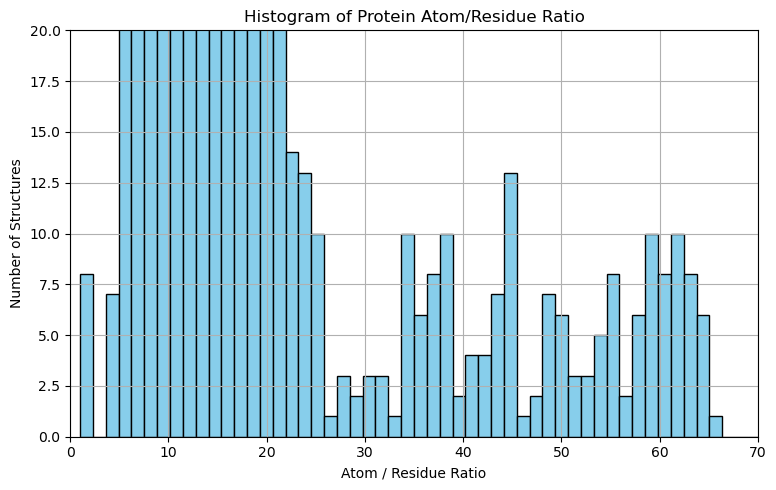

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 로드
csv_path = "/home/psh/protein-frame-flow/parse_general/meta/atom_residue_ratio.csv"
df = pd.read_csv(csv_path)

# 히스토그램 그리기 (x축 범위 제한)
plt.figure(figsize=(8, 5))
plt.hist(df["atom_residue_ratio"], bins=3000, color='skyblue', edgecolor='k')
plt.xlabel("Atom / Residue Ratio")
plt.ylabel("Number of Structures")
plt.title("Histogram of Protein Atom/Residue Ratio")
plt.xlim(0, 70)  # 👈 x축 범위 제한
plt.grid(True)
plt.tight_layout()
plt.ylim(0,20)
# 저장
plt.savefig("protein_atom_residue_ratio_histogram_limited.png", dpi=300)
plt.show()

In [20]:
import pandas as pd

# CSV 파일 로드
csv_path = "/home/psh/protein-frame-flow/parse_general/meta/atom_residue_ratio.csv"
df = pd.read_csv(csv_path)

# 5.0 미만인 행 필터링 후 pdb 열 출력
filtered_pdbs = df[df["atom_residue_ratio"] > 30.0]
print(filtered_pdbs.to_string(index=False))

 pdb  atom_residue_ratio
1cm4           31.254658
1hc0           77.829457
2d6b           78.604651
2q3m          129.915493
2q3o          123.475410
2q3p           31.764706
2q3r          125.264957
2q3t          132.628099
2q3u           63.551821
2q3v           31.702128
2q3w           61.284404
2q40          125.760933
2q42          124.598425
2q43          123.264000
2q46           60.332016
2q48           58.866667
2q4f           63.217391
2q4g           60.941980
2q4h           63.337662
2q4i           62.705202
2q4j           62.268852
2q4m          127.100000
2q4n           62.887417
2q4s          130.098361
2q4v           64.051447
2q4w          125.515528
2q4z          126.666667
2q52           65.009709
2ull          112.404040
3b2c           38.500000
3tgn           33.277108
4cbn         1150.271930
4cg2         1165.247148
4kin           33.836478
4kjj           36.295597
4kjk           35.675000
4m7k          298.153846
4m82          151.817027
4p3m         2616.333333


In [16]:
import os

# 기준 디렉토리
meta_dir = "/home/psh/data/general/meta"

# 제거할 PDB ID 목록
target_ids = {
    "1c53", "1cwn", "1ian", "1ilt", "1mar",
    "1tgl", "1wzb", "1ym8", "2blm", "2q33",
    "3cbh", "3gnz", "3ipj", "4gls", "4ttj"
}

# 디렉토리 순회
for filename in os.listdir(meta_dir):
    filepath = os.path.join(meta_dir, filename)
    if not os.path.isfile(filepath):
        continue

    # 해당 파일에 target PDB ID가 하나라도 포함되면 삭제
    if filename.replace('.pkl', '') in target_ids:
        os.remove(filepath)
        print(f"❌ 삭제됨: {filename}")


❌ 삭제됨: 1ian.pkl
❌ 삭제됨: 1ilt.pkl
❌ 삭제됨: 1wzb.pkl
❌ 삭제됨: 1tgl.pkl
❌ 삭제됨: 1mar.pkl
❌ 삭제됨: 1c53.pkl
❌ 삭제됨: 2blm.pkl
❌ 삭제됨: 1cwn.pkl
❌ 삭제됨: 2q33.pkl
❌ 삭제됨: 1ym8.pkl
❌ 삭제됨: 3gnz.pkl
❌ 삭제됨: 3cbh.pkl
❌ 삭제됨: 3ipj.pkl
❌ 삭제됨: 4gls.pkl
❌ 삭제됨: 4ttj.pkl


In [18]:
import pandas as pd

# 대상 CSV 파일 경로
csv_path = "/home/psh/data/general/meta/metadata.csv"
output_path = "/home/psh/data/general/meta/metadata_atom_filtered.csv"
# 삭제 대상 PDB ID 목록
target_ids = {
    "1c53", "1cwn", "1ian", "1ilt", "1mar",
    "1tgl", "1wzb", "1ym8", "2blm", "2q33",
    "3cbh", "3gnz", "3ipj", "4gls", "4ttj"
}

# CSV 로드
df = pd.read_csv(csv_path)

# 대상 ID가 포함된 행 삭제 (pdb id 열 이름이 'pdb'라고 가정)
df_filtered = df[~df["pdb_name"].isin(target_ids)]

# 결과 덮어쓰기 저장
df_filtered.to_csv(output_path, index=False)
print(f"✅ 삭제 완료: {len(df) - len(df_filtered)}개 행 제거됨")

✅ 삭제 완료: 15개 행 제거됨


## 모종의 이유로 seq_len이 1~2로 잡히는 샘플들 

In [40]:
import pandas as pd

# CSV 파일 경로
csv_path = '/home/psh/data/general/meta/metadata.csv'

# CSV 읽기
df = pd.read_csv(csv_path)

# seq_len이 3 미만인 행 필터링
filtered_df = df[df['seq_len'] < 3]

# pdb_name과 seq_len 열만 선택
result = filtered_df[['pdb_name', 'seq_len']]

print(result)

# 필요하면 CSV로 저장
# result.to_csv('/home/psh/protein-frame-flow/parse_general/meta/filtered_seq_len_less_than_4.csv', index=False)


      pdb_name  seq_len
171       1a7z        2
204       1aa5        2
835       1c0q        2
836       1c0r        2
3314      1hc0        1
...        ...      ...
76450     7ltb        2
76725     7mhl        1
76726     7mhm        1
76727     7mho        1
76728     7mhq        1

[93 rows x 2 columns]
